#### 1 Introduction

This analysis integrates the outputs of three team analyses:

- Identification of trauma hospitals that do not have burn capability.
- Measurement of how far these trauma hospitals are from the nearest burn center. 
- Nearby nurn centers capacity

The goal of this analysis is to prioritize hospitals where improved referral pathways could reduce delays in access to specialized burn care.

#### 2. Importing Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

#### 3. Loading results from the previous Analysis

In [13]:
referral_results = pd.read_csv("../outputs/analysis1_referral_results.csv")
distance_results = pd.read_csv("../outputs/analysis2_distance_results.csv")
capacity_results = pd.read_csv("../outputs/analysis3_capacity_results.csv")



# From Analysis 3 - capacity score
capacity_results["bed_score"] = 1 - (
    capacity_results["BURN_BEDS"] / capacity_results["BURN_BEDS"].max()
)

capacity_results["capacity_score"] = capacity_results["bed_score"]

#### 4. Merging Analysis

In [14]:
df = referral_results.merge(distance_results, on="HOSPITAL_NAME")

df = df.merge(
    capacity_results,
    left_on="HOSPITAL_NAME",
    right_on="HOSPITAL_NAME",
    how="left"
)

display(df.head())

,HOSPITAL_NAME,CITY_x,STATE_x,STATE_FULL_x,TRAUMA_ADULT_x,TRAUMA_PEDS_x,BURN_ADULT_x,BURN_PEDS_x,adult_gap_flag,peds_gap_flag,...,BC_STATE_DESIGNATED,PHONE,FULL_ADDRESS,LATITUDE,LONGITUDE,nearest_burn_distance_miles,STATE_FULL,BURN_BEDS_y,bed_score,capacity_score
0,Alaska Native Medical Center,Anchorage,AK,Alaska,1,1,0,0,1,1,...,NaN,(907) 563-2662,"4315 Diplomacy Dr, Anchorage, AK 99508",61.182772,-149.800177,1430.846678,Alaska,0.0,1.0,1.0
1,Providence Alaska Medical Center/Children's Ho...,Anchorage,AK,Alaska,1,1,0,0,1,1,...,NaN,(907) 562-2211,"3200 Providence Dr, Anchorage, AK 99508",61.187168,-149.819439,1431.555391,Alaska,0.0,1.0,1.0
2,Banner Desert Medical Center/Banner Children's...,Mesa,AZ,Arizona,1,1,0,0,1,1,...,NaN,(480) 412-3000,"1400 S Dobson Rd, Mesa, AZ 85202",33.390213,-111.878137,9.622539,Arizona,0.0,1.0,1.0
3,Loma Linda University Medical Center/Loma Lind...,Loma Linda,CA,California,1,1,0,0,1,1,...,NaN,(909) 558-4000,"11234 Anderson St, Loma Linda, CA 92354",34.049112,-117.263435,5.274531,California,0.0,1.0,1.0
4,Providence Mission Hospital,Mission Viejo,CA,California,1,1,0,0,1,1,...,NaN,(949) 364-1400,"27700 Medical Center Rd, Mission Viejo, CA 92691",33.561486,-117.665119,16.434942,California,0.0,1.0,1.0


#### 5. Decision Model

In [15]:
df["distance_score"] = df["nearest_burn_distance_miles"] / df["nearest_burn_distance_miles"].max()

df["priority_score"] = (
    df["distance_score"] * 0.6 +
    df["capacity_score"] * 0.4
)

#### 6. Identify Priority Hospitals

In [16]:
top20 = df.sort_values(
    "priority_score",
    ascending=False
).head(20)

#### 7. Visualization

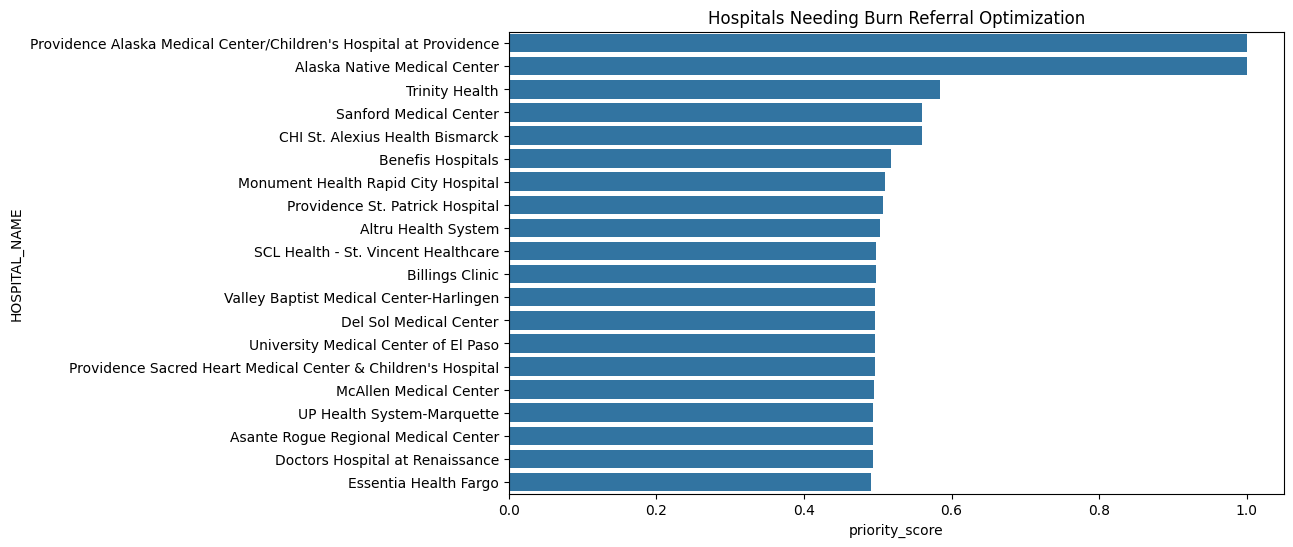

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top20,
    y="HOSPITAL_NAME",
    x="priority_score"
)

plt.title("Hospitals Needing Burn Referral Optimization")
plt.show()

#### 8. Visualization

In [ ]:
top20.to_csv("../outputs/analysis4_optimization_results.csv", index=False)